# Detección de Noticias Falsas con Redes Neuronales Profundas
## Proyecto Semestral — Modelado Predictivo 2026

**ESCOM — Instituto Politécnico Nacional**

---

# ¿Como sabrian si una noticia es falsa solo leyendo el texto?

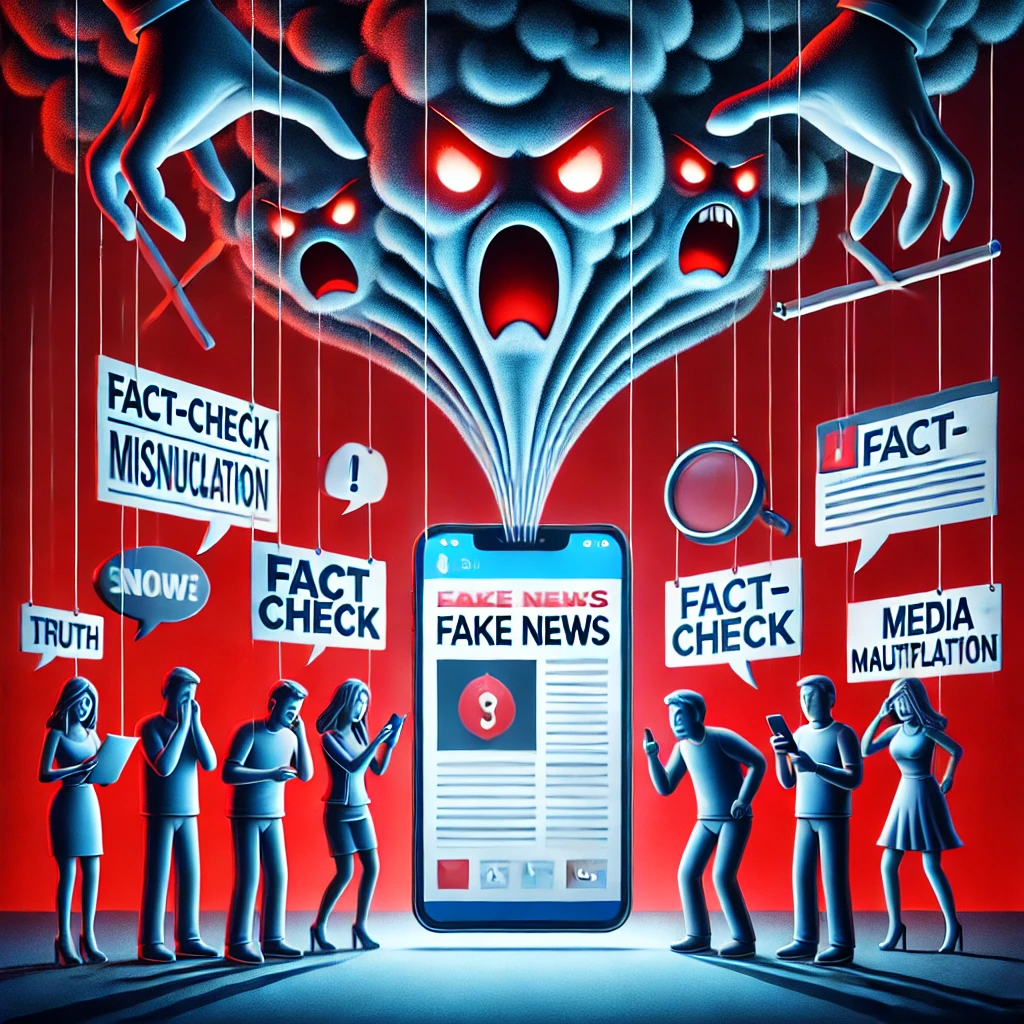

## 1. El Problema: Noticias Falsas en la Era Digital

Las **noticias falsas** (fake news) son contenidos informativos deliberadamente fabricados que imitan el formato de medios legítimos para engañar al lector.

### ¿Por qué es un problema urgente?

- **Escala masiva:** En redes sociales, una noticia falsa se comparte **6 veces más rápido** que una verdadera (Vosoughi et al., *Science*, 2018)
- **Impacto en elecciones:** La desinformación ha influido documentadamente en procesos electorales en múltiples países
- **Salud pública:** Durante la pandemia de COVID-19, la OMS acuñó el término *infodemia* para describir la epidemia paralela de desinformación
- **Erosión de confianza:** El 67% de los adultos en Latinoamérica reportan dificultad para distinguir noticias reales de falsas (Reuters Institute, 2023)

### ¿Puede una máquina detectar noticias falsas?

Sí, y cada vez mejor. La detección automática es un campo activo de investigación en NLP:

| Enfoque | Técnica | Accuracy aproximado |
|---------|---------|--------------------|
| Clásico | TF-IDF + Logistic Regression | ~93-94% |
| Redes neuronales | CNN sobre texto (TextCNN) | ~96-97% |
| Transformers | BERT fine-tuned | ~98.7% |

En este proyecto, ustedes construirán modelos que cubren los **dos primeros niveles**, y compararán contra el tercero como referencia.

## 2. Objetivo del Proyecto

Diseñar, implementar y evaluar un **sistema de clasificación binaria de texto** que determine si una noticia es **Real** o **Falsa**, aplicando el ciclo completo de un proyecto de aprendizaje profundo:

```
Datos → Exploración → Baselines → Pipeline neuronal → Modelo DNN → Experimentos → NAS → Análisis
```

### Preguntas que resolveremos:
1. ¿Qué tan bien funcionan los métodos clásicos (TF-IDF + modelos lineales) para este problema?
2. ¿Una red neuronal convolucional (TextCNN) supera a los baselines clásicos?
3. ¿Los embeddings preentrenados (GloVe) mejoran el rendimiento vs. embeddings aleatorios?
4. ¿Qué hiperparámetros tienen mayor impacto en el rendimiento?
5. ¿Un algoritmo genético puede encontrar una arquitectura mejor que la diseñada manualmente?

## 3. Dataset: WELFake

Usaremos el dataset **WELFake** (Word Embedding over Linguistic Features for Fake News Detection), publicado por Verma et al. (2021) en IEEE Transactions on Computational Social Systems.

| Atributo | Detalle |
|----------|--------|
| Muestras | 72,134 noticias en inglés |
| Clases | 0 = Real, 1 = Fake (balanceado ~50/50) |
| Columnas | `title` (titular), `text` (cuerpo), `label` |
| Origen | Combinación de 4 fuentes: Kaggle, McIntire, Reuters, BuzzFeed |
| Disponibilidad | Kaggle: saurabhshahane/fake-news-classification |

> **Descarga:** https://www.kaggle.com/datasets/saurabhshahane/fake-news-classification

### ¿Por qué este dataset?
- Es **público y accesible** desde Kaggle
- Tiene **benchmarks documentados** para comparar resultados
- Es suficientemente grande para entrenar redes neuronales
- Está **balanceado**, lo que simplifica la evaluación
- Combina múltiples fuentes, lo que lo hace más robusto que datasets de una sola fuente

## 4. ¿Qué Van a Aprender?

Este proyecto está diseñado para construir competencias progresivamente. Cada semana agrega una capa de complejidad sobre la anterior.

### Conceptos teóricos
- Procesamiento de Lenguaje Natural (NLP) y representación de texto
- Bag of Words, TF-IDF y sus limitaciones para redes neuronales
- Word embeddings: representaciones densas y transfer learning con GloVe
- Convoluciones 1D sobre texto (TextCNN, Kim 2014)
- Hiperparámetros vs. parámetros del modelo
- Regularización: dropout, weight decay, early stopping
- Neural Architecture Search (NAS) con algoritmos genéticos

### Habilidades técnicas
- Análisis exploratorio de datos textuales
- Construcción de pipelines de preprocesamiento reproducibles
- Implementación de modelos en PyTorch (Dataset, DataLoader, nn.Module)
- Diseño de experimentos controlados (variar una variable a la vez)
- Evaluación con métricas apropiadas (F1, precision, recall, matriz de confusión)
- Uso de DEAP para algoritmos evolutivos
- Visualización e interpretación de resultados (t-SNE, análisis de gradientes)

### Habilidades profesionales
- Documentar decisiones de diseño y justificarlas
- Analizar errores del modelo y proponer mejoras
- Redactar un reporte técnico estructurado
- Comunicar resultados en una presentación oral

## 5. Arquitectura del Proyecto

El proyecto sigue una estructura modular con notebooks para la experimentación y módulos Python reutilizables:

```
ModeladoPredictivo2026/
├── notebooks/                  ← Notebooks de cada semana
│   ├── 00_FakeNews.ipynb           Introducción (este notebook)
│   ├── 01_EDA.ipynb                Exploración de datos
│   ├── 02_Baselines.ipynb          Baselines clásicos
│   ├── 03_TextPipeline.ipynb       Pipeline neuronal
│   ├── 04_TextCNN.ipynb            Arquitectura TextCNN
│   ├── 05_Experiments.ipynb        Experimentación
│   ├── 06_NAS_GA.ipynb             NAS con algoritmo genético
│   └── 07_Analysis.ipynb           Análisis final
├── src/                        ← Módulos reutilizables
│   ├── preprocess.py               Limpieza de texto
│   ├── dataset.py                  Vocabulario, Dataset, DataLoader
│   ├── model.py                    Arquitectura TextCNN
│   ├── train.py                    Entrenamiento y early stopping
│   ├── evaluate.py                 Métricas y visualización
│   └── nas_ga.py                   Algoritmo genético con DEAP
├── data/                       ← Dataset WELFake
├── embeddings/                 ← GloVe preentrenado
├── results/                    ← CSVs y gráficas generadas
└── requirements.txt
```

### ¿Por qué esta estructura?
- Los **notebooks** contienen teoría, código y análisis — son tu cuaderno de laboratorio
- Los **módulos src/** evitan duplicar código entre notebooks y facilitan el mantenimiento
- Separar datos, código y resultados es una buena práctica de ingeniería de software

## 6. Cronograma: 7 Semanas

### Semana 1 — Exploración de Datos
**Notebook:** `01_EDA.ipynb`

| Qué harán | Qué entregarán |
|-----------|----------------|
| Cargar y explorar el dataset WELFake | Notebook ejecutado con gráficas |
| Analizar distribución de clases y longitudes | Respuestas a preguntas de reflexión |
| Manejar nulos y duplicados | Decisiones documentadas y justificadas |
| Generar nubes de palabras por clase | Observaciones sobre diferencias entre clases |

**Conceptos clave:** NLP, clasificación de texto, análisis exploratorio, manejo de datos faltantes.

---

### Semana 2 — Baselines Clásicos
**Notebook:** `02_Baselines.ipynb`

| Qué harán | Qué entregarán |
|-----------|----------------|
| Implementar limpieza de texto | Pipeline de preprocesamiento funcional |
| Extraer features con TF-IDF | Representación vectorial del corpus |
| Entrenar Logistic Regression y SVM | Dos modelos baseline entrenados |
| Evaluar con F1, precision, recall | Tabla comparativa con métricas completas |

**Conceptos clave:** Bag of Words, TF-IDF, regresión logística, SVM, métricas de clasificación, matriz de confusión.

---

### Semana 3 — Pipeline Neuronal de Texto
**Notebook:** `03_TextPipeline.ipynb`

| Qué harán | Qué entregarán |
|-----------|----------------|
| Construir vocabulario (top 20K palabras) | Mapeo word → index funcional |
| Tokenizar y convertir texto a índices | Secuencias numéricas de longitud fija |
| Implementar padding y truncado | Tensores listos para la red neuronal |
| Cargar embeddings GloVe preentrenados | Matriz de embeddings alineada con el vocabulario |

**Conceptos clave:** Limitaciones de TF-IDF para DNN, word embeddings, transfer learning, Dataset/DataLoader de PyTorch.

---

### Semana 4 — Arquitectura TextCNN
**Notebook:** `04_TextCNN.ipynb`

| Qué harán | Qué entregarán |
|-----------|----------------|
| Implementar TextCNN (Kim, 2014) | Modelo con 3 ramas Conv1D funcional |
| Entrenar con embeddings aleatorios | Curvas de entrenamiento y métricas |
| Entrenar con embeddings GloVe | Comparación random vs. preentrenado |
| Comparar contra baselines | Tabla: LR vs. SVM vs. TextCNN |

**Conceptos clave:** Conv1D sobre texto, kernels de diferentes tamaños, max-over-time pooling, BCEWithLogitsLoss, Adam optimizer.

---

### Semana 5 — Experimentación Sistemática
**Notebook:** `05_Experiments.ipynb`

| Qué harán | Qué entregarán |
|-----------|----------------|
| Sweep de learning rate [1e-2, 1e-3, 1e-4] | Resultados tabulados por experimento |
| Sweep de num_filters [50, 100, 200] | CSV con todos los experimentos |
| Sweep de dropout [0.3, 0.5, 0.7] | Mejor configuración identificada |
| Comparar campos de entrada (title/text/ambos) | Análisis de al menos 10 errores |

**Conceptos clave:** Hiperparámetro vs. parámetro, ceteris paribus, regularización (dropout, weight decay, early stopping), análisis de errores.

---

### Semana 6 — NAS con Algoritmo Genético
**Notebook:** `06_NAS_GA.ipynb`

| Qué harán | Qué entregarán |
|-----------|----------------|
| Definir espacio de búsqueda (5 genes) | Cromosoma codificado y decodificable |
| Configurar DEAP (selección, cruce, mutación) | AG funcional con fitness proxy |
| Evolucionar 10 individuos × 10 generaciones | Curva de evolución (max y avg fitness) |
| Entrenar mejor individuo completamente | Comparación: manual vs. evolucionado |

**Conceptos clave:** NAS, algoritmos genéticos, cromosoma/gen, selección por torneo, cruce de un punto, mutación uniforme, fitness proxy.

---

### Semana 7 — Análisis Final, Reporte y Presentación
**Notebook:** `07_Analysis.ipynb`

| Qué harán | Qué entregarán |
|-----------|----------------|
| Tabla comparativa de los 5 modelos | Visualización t-SNE de embeddings |
| Análisis de palabras influyentes (gradientes) | Gráfica de palabras más relevantes |
| Comparación contra BERT (referencia) | Análisis crítico de limitaciones |
| Redactar reporte final | Reporte + presentación oral (12+5 min) |

**Conceptos clave:** PCA, t-SNE, análisis de gradientes, TextCNN vs. BERT, generalización, limitaciones del modelo.

## 7. Stack Tecnológico

| Herramienta | Uso | ¿Por qué? |
|-------------|-----|------------|
| **Python 3.9+** | Lenguaje base | Estándar en ML/NLP |
| **PyTorch** | Framework de deep learning | Flexible, debugging intuitivo, industria |
| **scikit-learn** | Baselines y métricas | TF-IDF, LogReg, SVM, F1, confusion matrix |
| **pandas / numpy** | Manipulación de datos | Carga CSV, estadísticas, arrays |
| **matplotlib** | Visualización | Gráficas, histogramas, curvas |
| **DEAP** | Algoritmo genético | Framework evolutivo para NAS |
| **Google Colab** | Entorno de ejecución | Gratuito, GPU opcional, sin instalación local |

### Instalación rápida
```python
!pip install torch scikit-learn pandas numpy matplotlib deap tqdm wordcloud
```

## 8. Entregables y Evaluación

### Entregables semanales
Cada semana deben entregar el **notebook ejecutado** (con todas las celdas corridas y las salidas visibles), incluyendo:
- Respuestas a las preguntas de reflexión
- Interpretación de resultados en las celdas markdown indicadas
- Código funcional sin errores

### Entregable final (Semana 7)

| Componente | Descripción |
|------------|-------------|
| **Notebooks 01-07** | Todos ejecutados, con respuestas y análisis |
| **Reporte técnico** | Documento con: Introducción, Dataset, Preprocesamiento, Baselines, TextCNN, Experimentos, NAS, Resultados, Conclusiones |
| **Presentación oral** | 12 minutos de exposición + 5 minutos de preguntas |
| **Código fuente** | Repositorio o carpeta con notebooks + src/ + datos |

## 9. Prerrequisitos

Para aprovechar al máximo este proyecto, necesitan:

| Prerrequisito | Nivel | ¿Dónde repasarlo? |
|---------------|-------|-------------------|
| Python | Intermedio (funciones, clases, listas) | Cualquier tutorial de Python 3 |
| pandas | Básico (DataFrames, filtros, groupby) | pandas en 10 min (documentación oficial) |
| Redes neuronales densas | Conceptual (capas, activaciones, backprop) | Material previo del curso |
| Álgebra lineal | Básico (vectores, matrices, producto punto) | Khan Academy |

**No necesitan experiencia previa en:**
- NLP o procesamiento de texto
- PyTorch (lo aprenderán en el camino)
- Algoritmos genéticos
- Convoluciones (se explican desde cero)

## 10. Configuración del Entorno

### Opción A: Google Colab (recomendada)
1. Subir la carpeta del proyecto a Google Drive
2. Abrir cada notebook desde Colab
3. Montar Drive para acceder a datos y módulos src/

### Opción B: Local
1. Instalar Python 3.9+
2. Crear un entorno virtual: `python -m venv venv`
3. Instalar dependencias: `pip install -r requirements.txt`
4. Abrir notebooks con Jupyter Lab o VS Code

### Datos necesarios
1. **Dataset WELFake:** Descargar de Kaggle y colocar en `data/WELFake_Dataset.csv`
   - https://www.kaggle.com/datasets/saurabhshahane/fake-news-classification
2. **Embeddings GloVe 6B 50d:** Descargar de Stanford NLP, extraer `glove.6B.50d.txt` en `embeddings/`
   - https://nlp.stanford.edu/data/glove.6B.zip

---

## ¡Comencemos!

Abran el notebook **`01_EDA.ipynb`** para iniciar la exploración del dataset.

Recuerden: cada notebook incluye secciones teóricas que deben leer antes de ejecutar el código. La teoría no es opcional — es parte del aprendizaje.

---
*Proyecto diseñado para Modelado Predictivo 2026 — ESCOM, IPN*